# 俄罗斯数据绘图分析

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
# 设置字体
matplotlib.rcParams['font.family'] = 'Microsoft YaHei, Times New Roman'
# 全局设置字号
plt.rcParams.update({
    'font.size': 20,  # 基础字号
    'axes.titlesize': 24,  # 标题字号
    'axes.labelsize': 28,  # 坐标轴标签字号
    'xtick.labelsize': 24,  # x轴刻度标签字号
    'ytick.labelsize': 24,  # y轴刻度标签字号
    'legend.fontsize': 18  # 图例字号
})
# 解决负号显示问题
matplotlib.rcParams['axes.unicode_minus'] = False

## 156个小室，1正2负

### 电流、电压、碱液温度、出口温度、碱液流量

In [4]:
folder_path = r"D:\Devs\Single_Stack_MLJ\data\raw\els"
def statistic_plot(file_name):
    # 拼接文件的完整路径
    file_full_path = os.path.join(folder_path, file_name)
    # 读取CSV文件（如果是Excel，替换为pd.read_excel）
    df_exp = pd.read_excel(file_full_path)
    # 步骤1：获取倒数3行的索引标签
    last_3_index = df_exp.index[-3:]  # 结果：Int64Index([7, 8, 9], dtype='int64')
    # 步骤2：合并需要删除的索引（0 + 倒数3行）
    drop_index = [0] + list(last_3_index)
    # 步骤3：执行删除
    df_exp.drop(index=drop_index, inplace=True)

    # 步骤1：获取第一列的列名
    first_col_name = df_exp.columns[0]
    # 步骤2：重命名第一列，生成新的DataFrame
    df_exp = df_exp.rename(columns={first_col_name: '日期'})

    # 批量解析为标准时间格式，生成新列"标准时间"
    format_pattern = "%Y年%m月%d日%H时%M分%S秒"
    df_exp["日期"] = pd.to_datetime(df_exp["日期"], format=format_pattern)

    # 创建图表和子图
    fig, ax1 = plt.subplots(figsize=(22, 20))
    plt.grid(True)
    
    # 绘制碱液流量曲线
    ax1.plot(df_exp['日期'], df_exp['电流'], c = '#1f77b4', alpha = 0.8,label = '电流 (A)')
    ax1.set_ylabel('电流 (A)', color='#1f77b4')
    ax1.margins(x=0)  # 仅消除x轴边距
    ax1.set_xlabel('日期')
    ax1.tick_params('y', colors='#1f77b4')
    ax1.set_ylim((2000, 8200))
    
    # 创建第二个y轴
    ax2 = ax1.twinx()
    
    # 绘制第电流曲线
    ax2.plot(df_exp['日期'], df_exp['电压'] / 78, alpha=0.8, c = '#7f7f7f', label = '小室电压 (V)')
    ax2.set_ylabel('小室电压 (V)', color='#7f7f7f')
    ax2.tick_params('y', colors='#7f7f7f')
    ax2.set_ylim(1.35, 2.3)
    
    # 创建第三个y轴
    ax3 = ax1.twinx()
    
    # 绘制电压曲线
    ax3.plot(df_exp['日期'],df_exp['碱液流量'], c = '#2ca02c', alpha = 0.8,label = '碱液流量 (m$^3$/h)')
    ax3.set_ylabel('碱液流量 (m$^3$/h)', color='#2ca02c')
    ax3.spines['right'].set_position(('outward', 100))
    ax3.tick_params('y', colors='#2ca02c')
    ax3.set_ylim((6.5, 12.5))
    
    # 创建第四个y轴
    ax4 = ax1.twinx()
    
    # 绘制出口温度曲线
    ax4.plot(df_exp['日期'],df_exp['碱液温度'], c = '#d62728', label = '碱液温度 (℃)')
    ax4.set_ylabel('碱液温度 (℃)', color='#d62728')
    ax4.spines['right'].set_position(('outward', 200))
    ax4.set_ylim(37, 82)
    ax4.tick_params('y', colors='#d62728')
    
    # 创建第五个y轴
    ax5 = ax1.twinx()
    
    # 绘制出口温度曲线
    ax5.plot(df_exp['日期'],(df_exp['碱液温度'] + df_exp['氢槽温'])/2, c = '#e377c2', label = '出口温度 (℃)')
    ax5.set_ylabel('出口温度 (℃)', color='#e377c2')
    ax5.spines['right'].set_position(('outward', 300))
    ax5.set_ylim(37, 82)
    ax5.tick_params('y', colors='#e377c2')
    
    # 添加图例
    ax1.set_title(os.path.splitext(file_name)[0], fontsize=30)
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    lines4, labels4 = ax4.get_legend_handles_labels()
    lines5, labels5 = ax5.get_legend_handles_labels()
    ax1.legend(lines + lines2 + lines3 + lines4 + lines5, labels + labels2 + labels3 + labels4 + labels5, loc='upper center',
               bbox_to_anchor=(0.55, -0.05), ncol=5, frameon=True, fancybox=True, shadow=True, fontsize=28)
    
    # 显示图表
    plt.show()

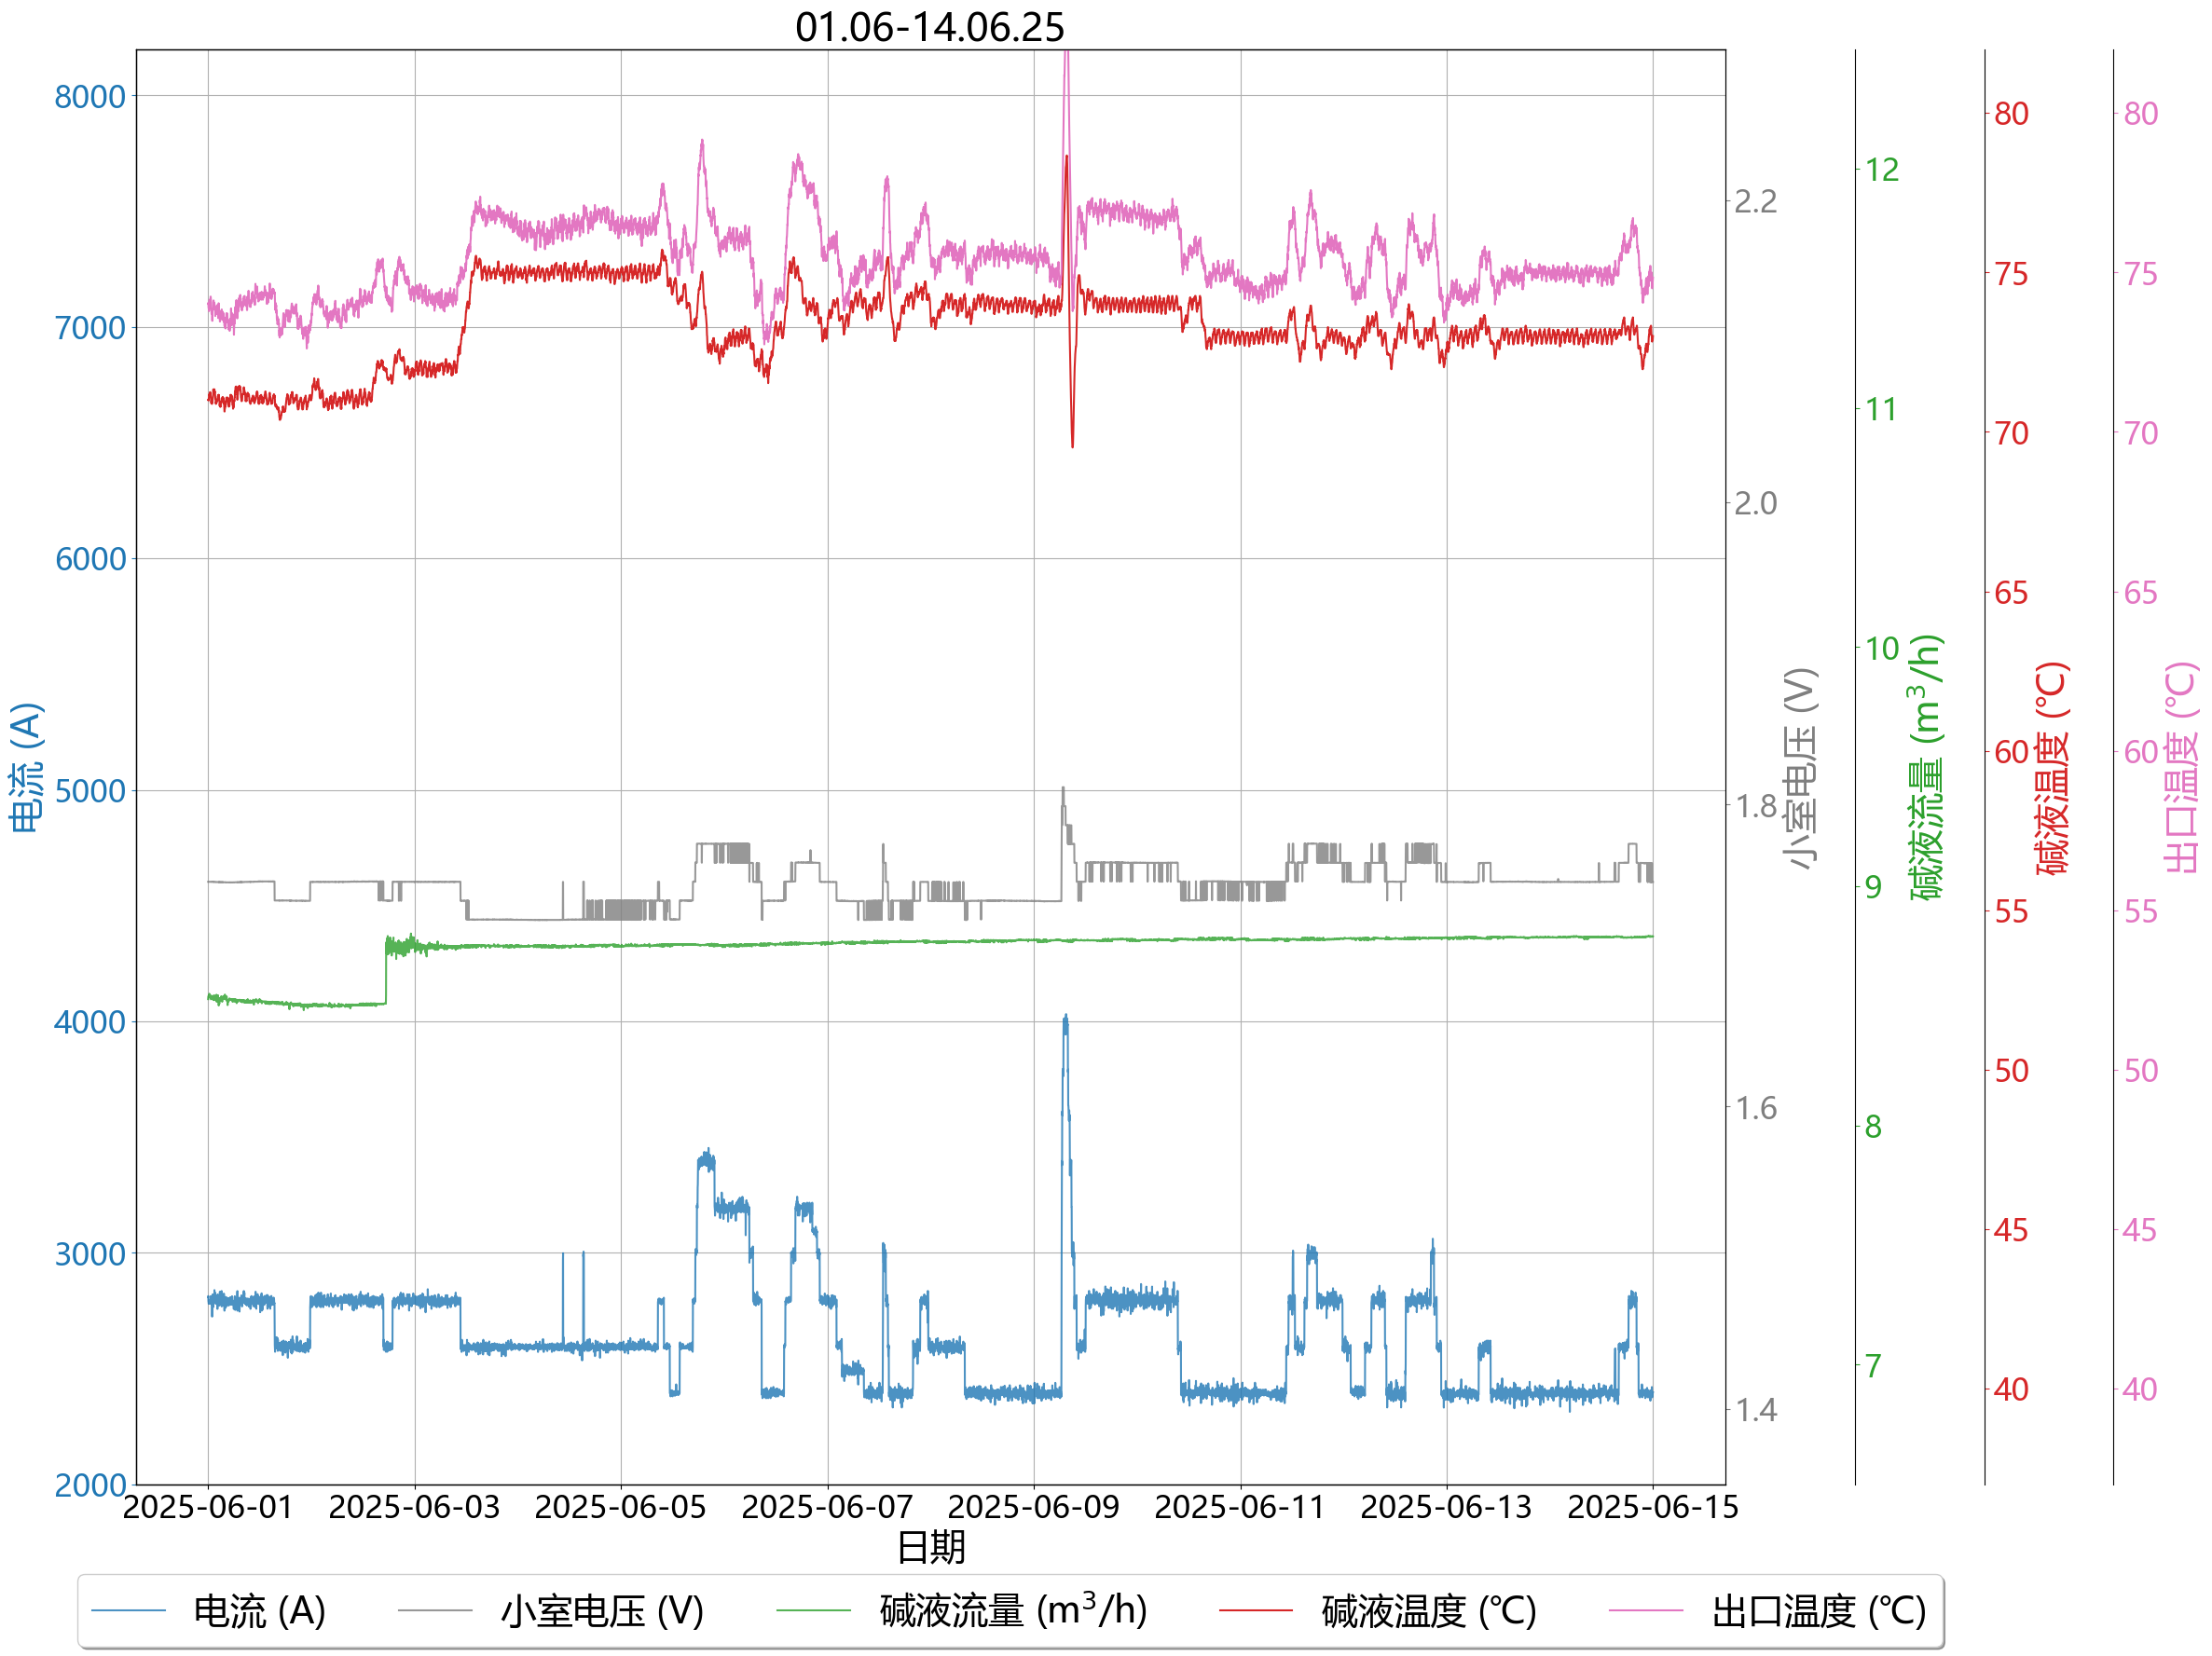

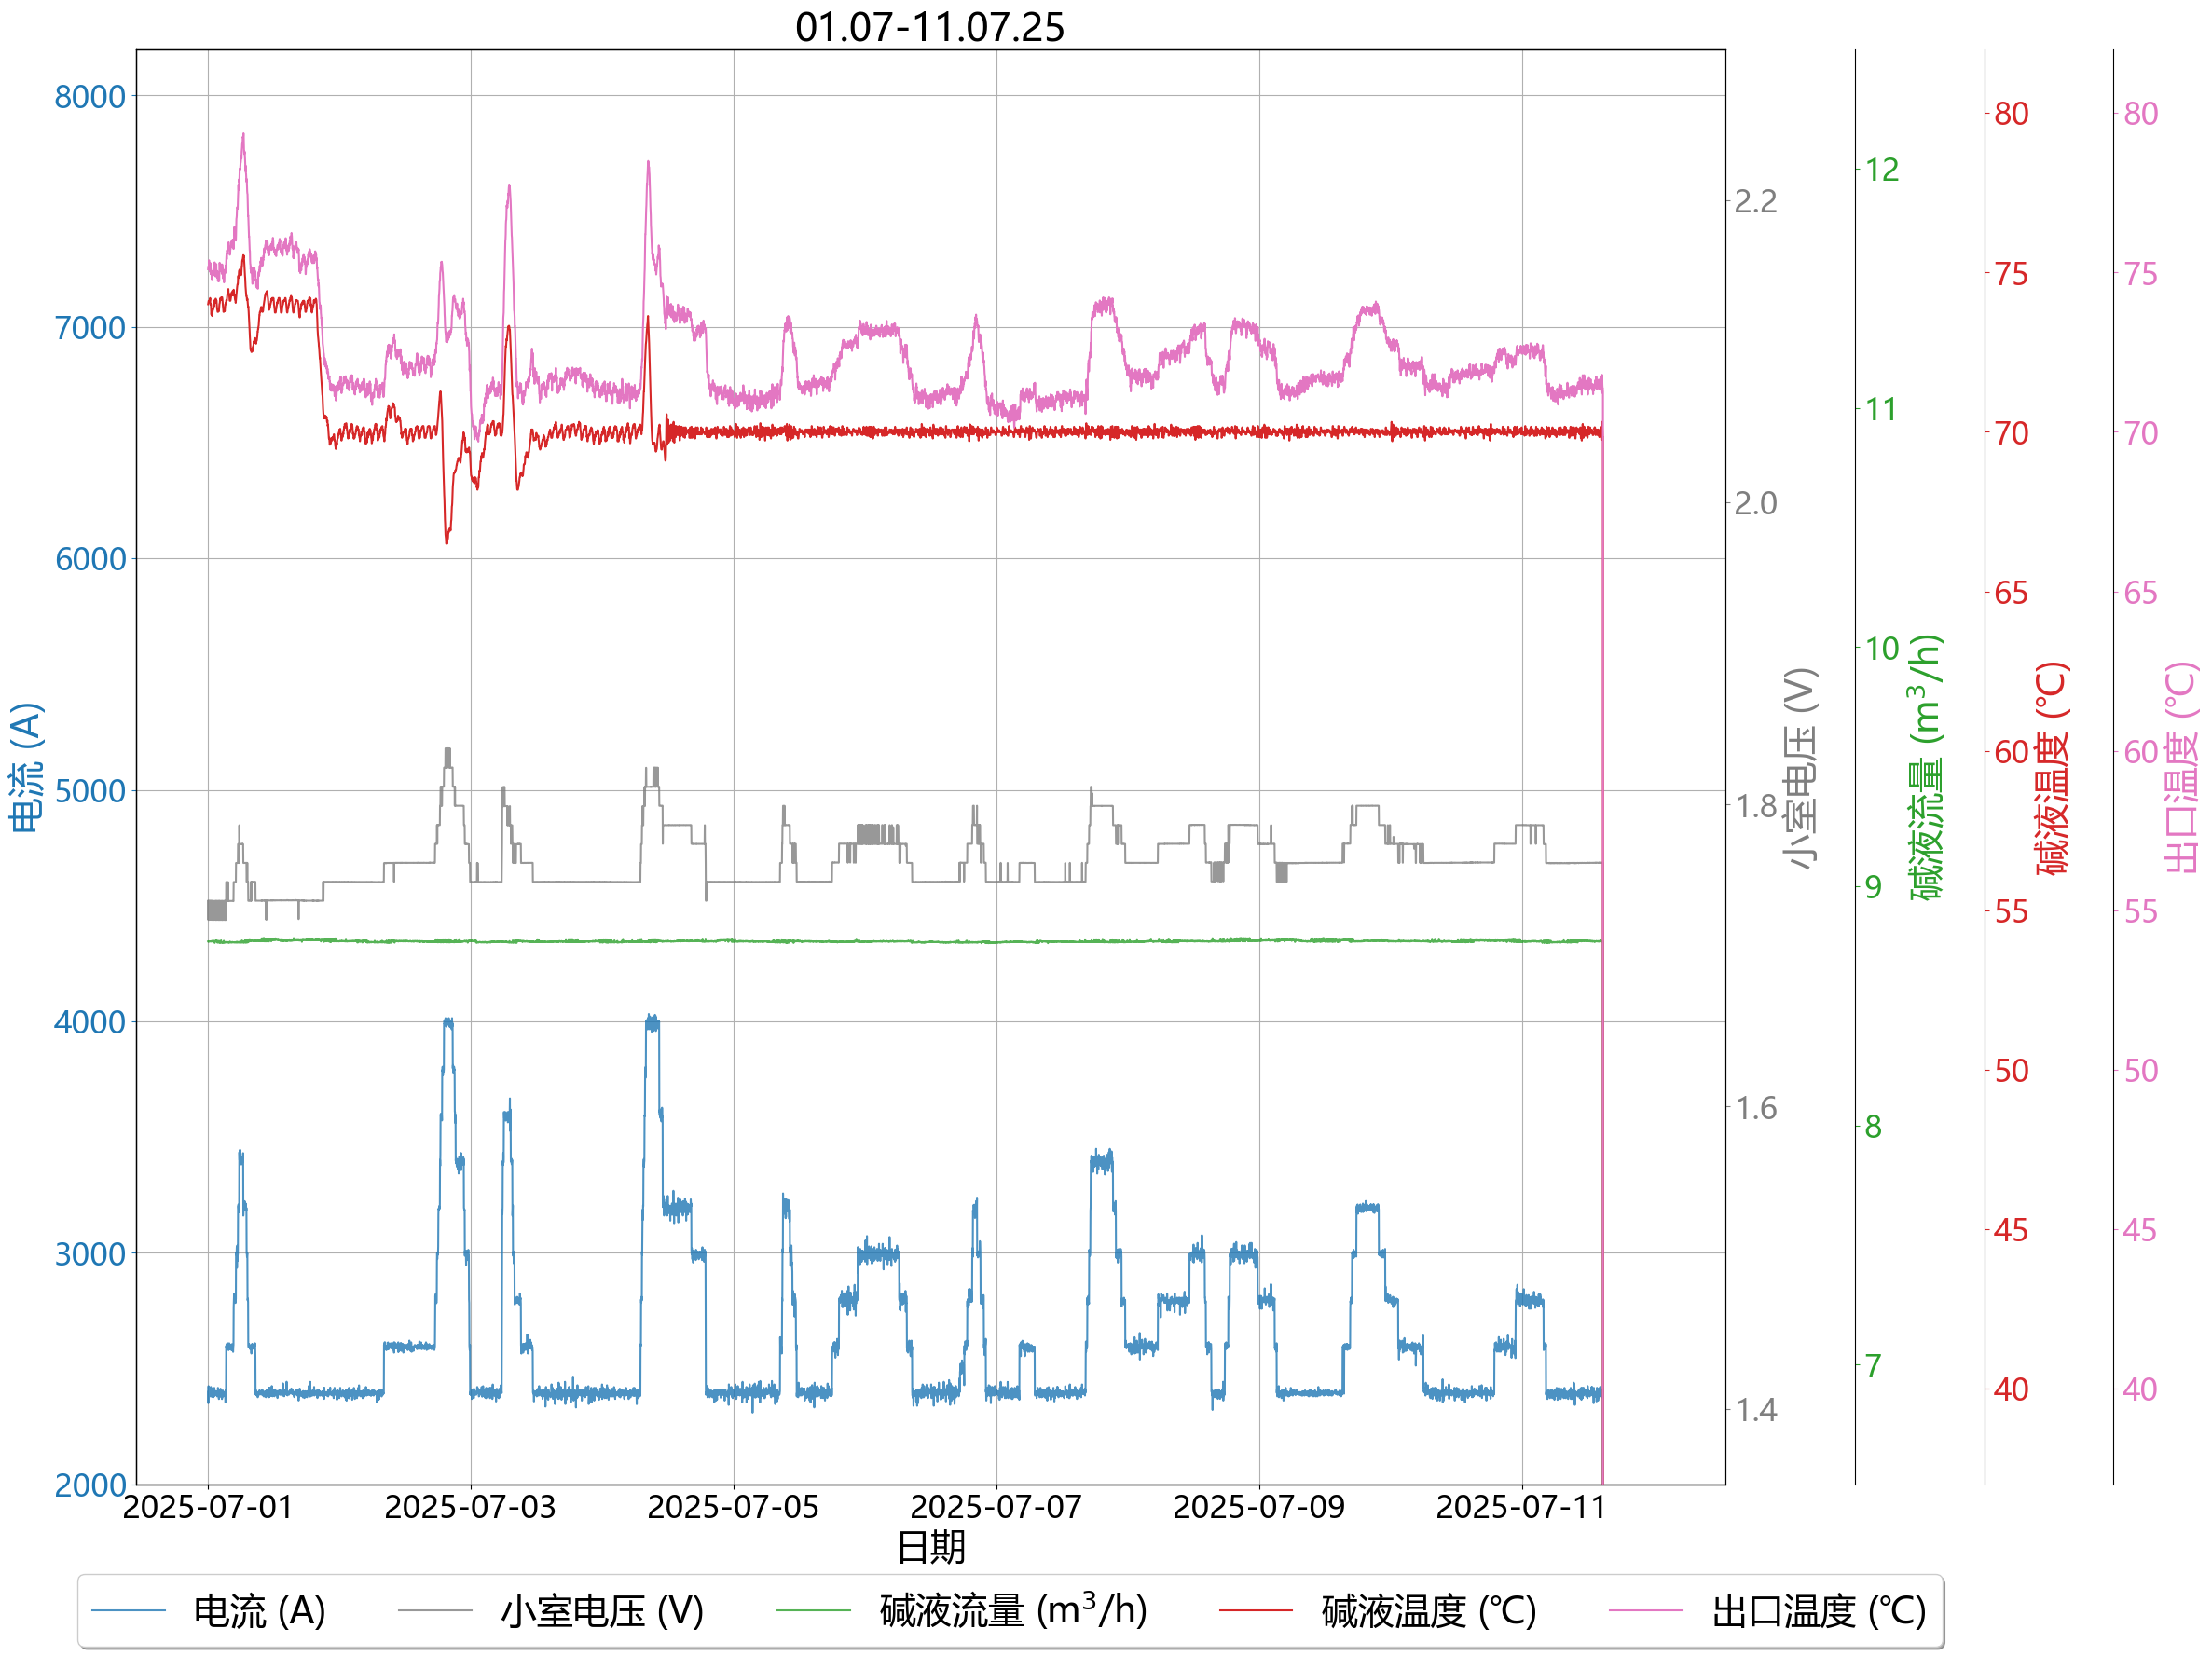

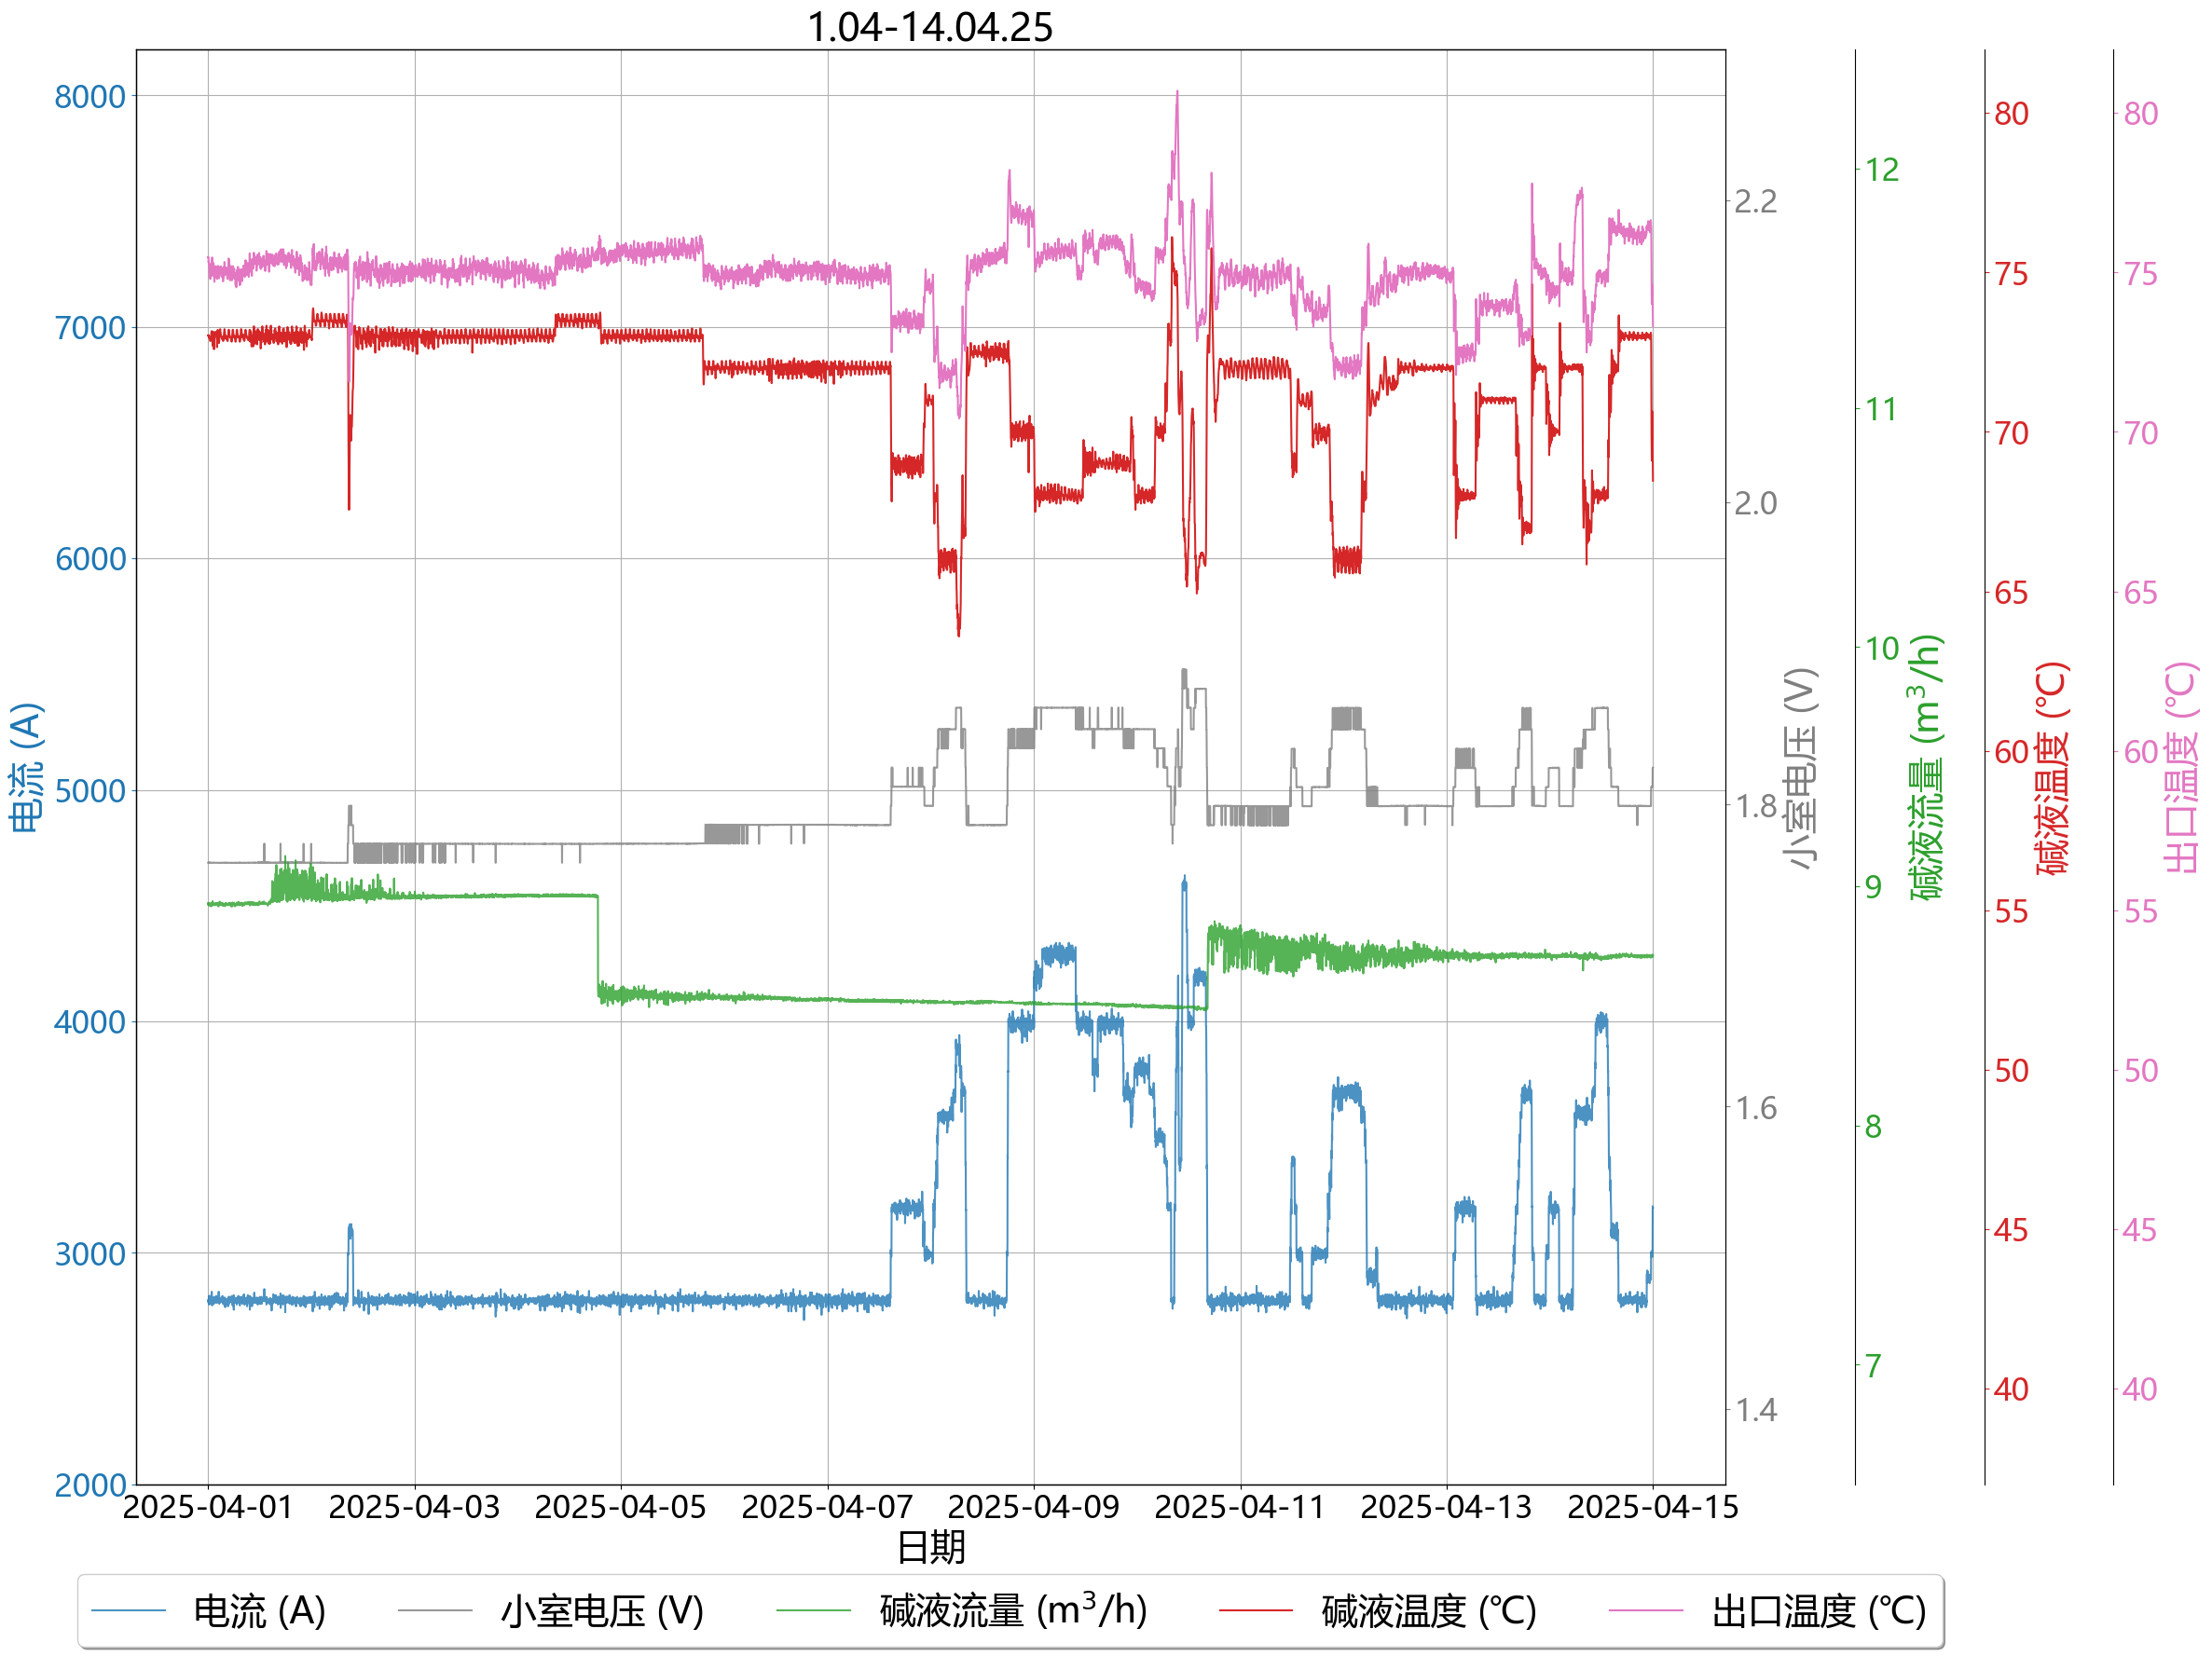

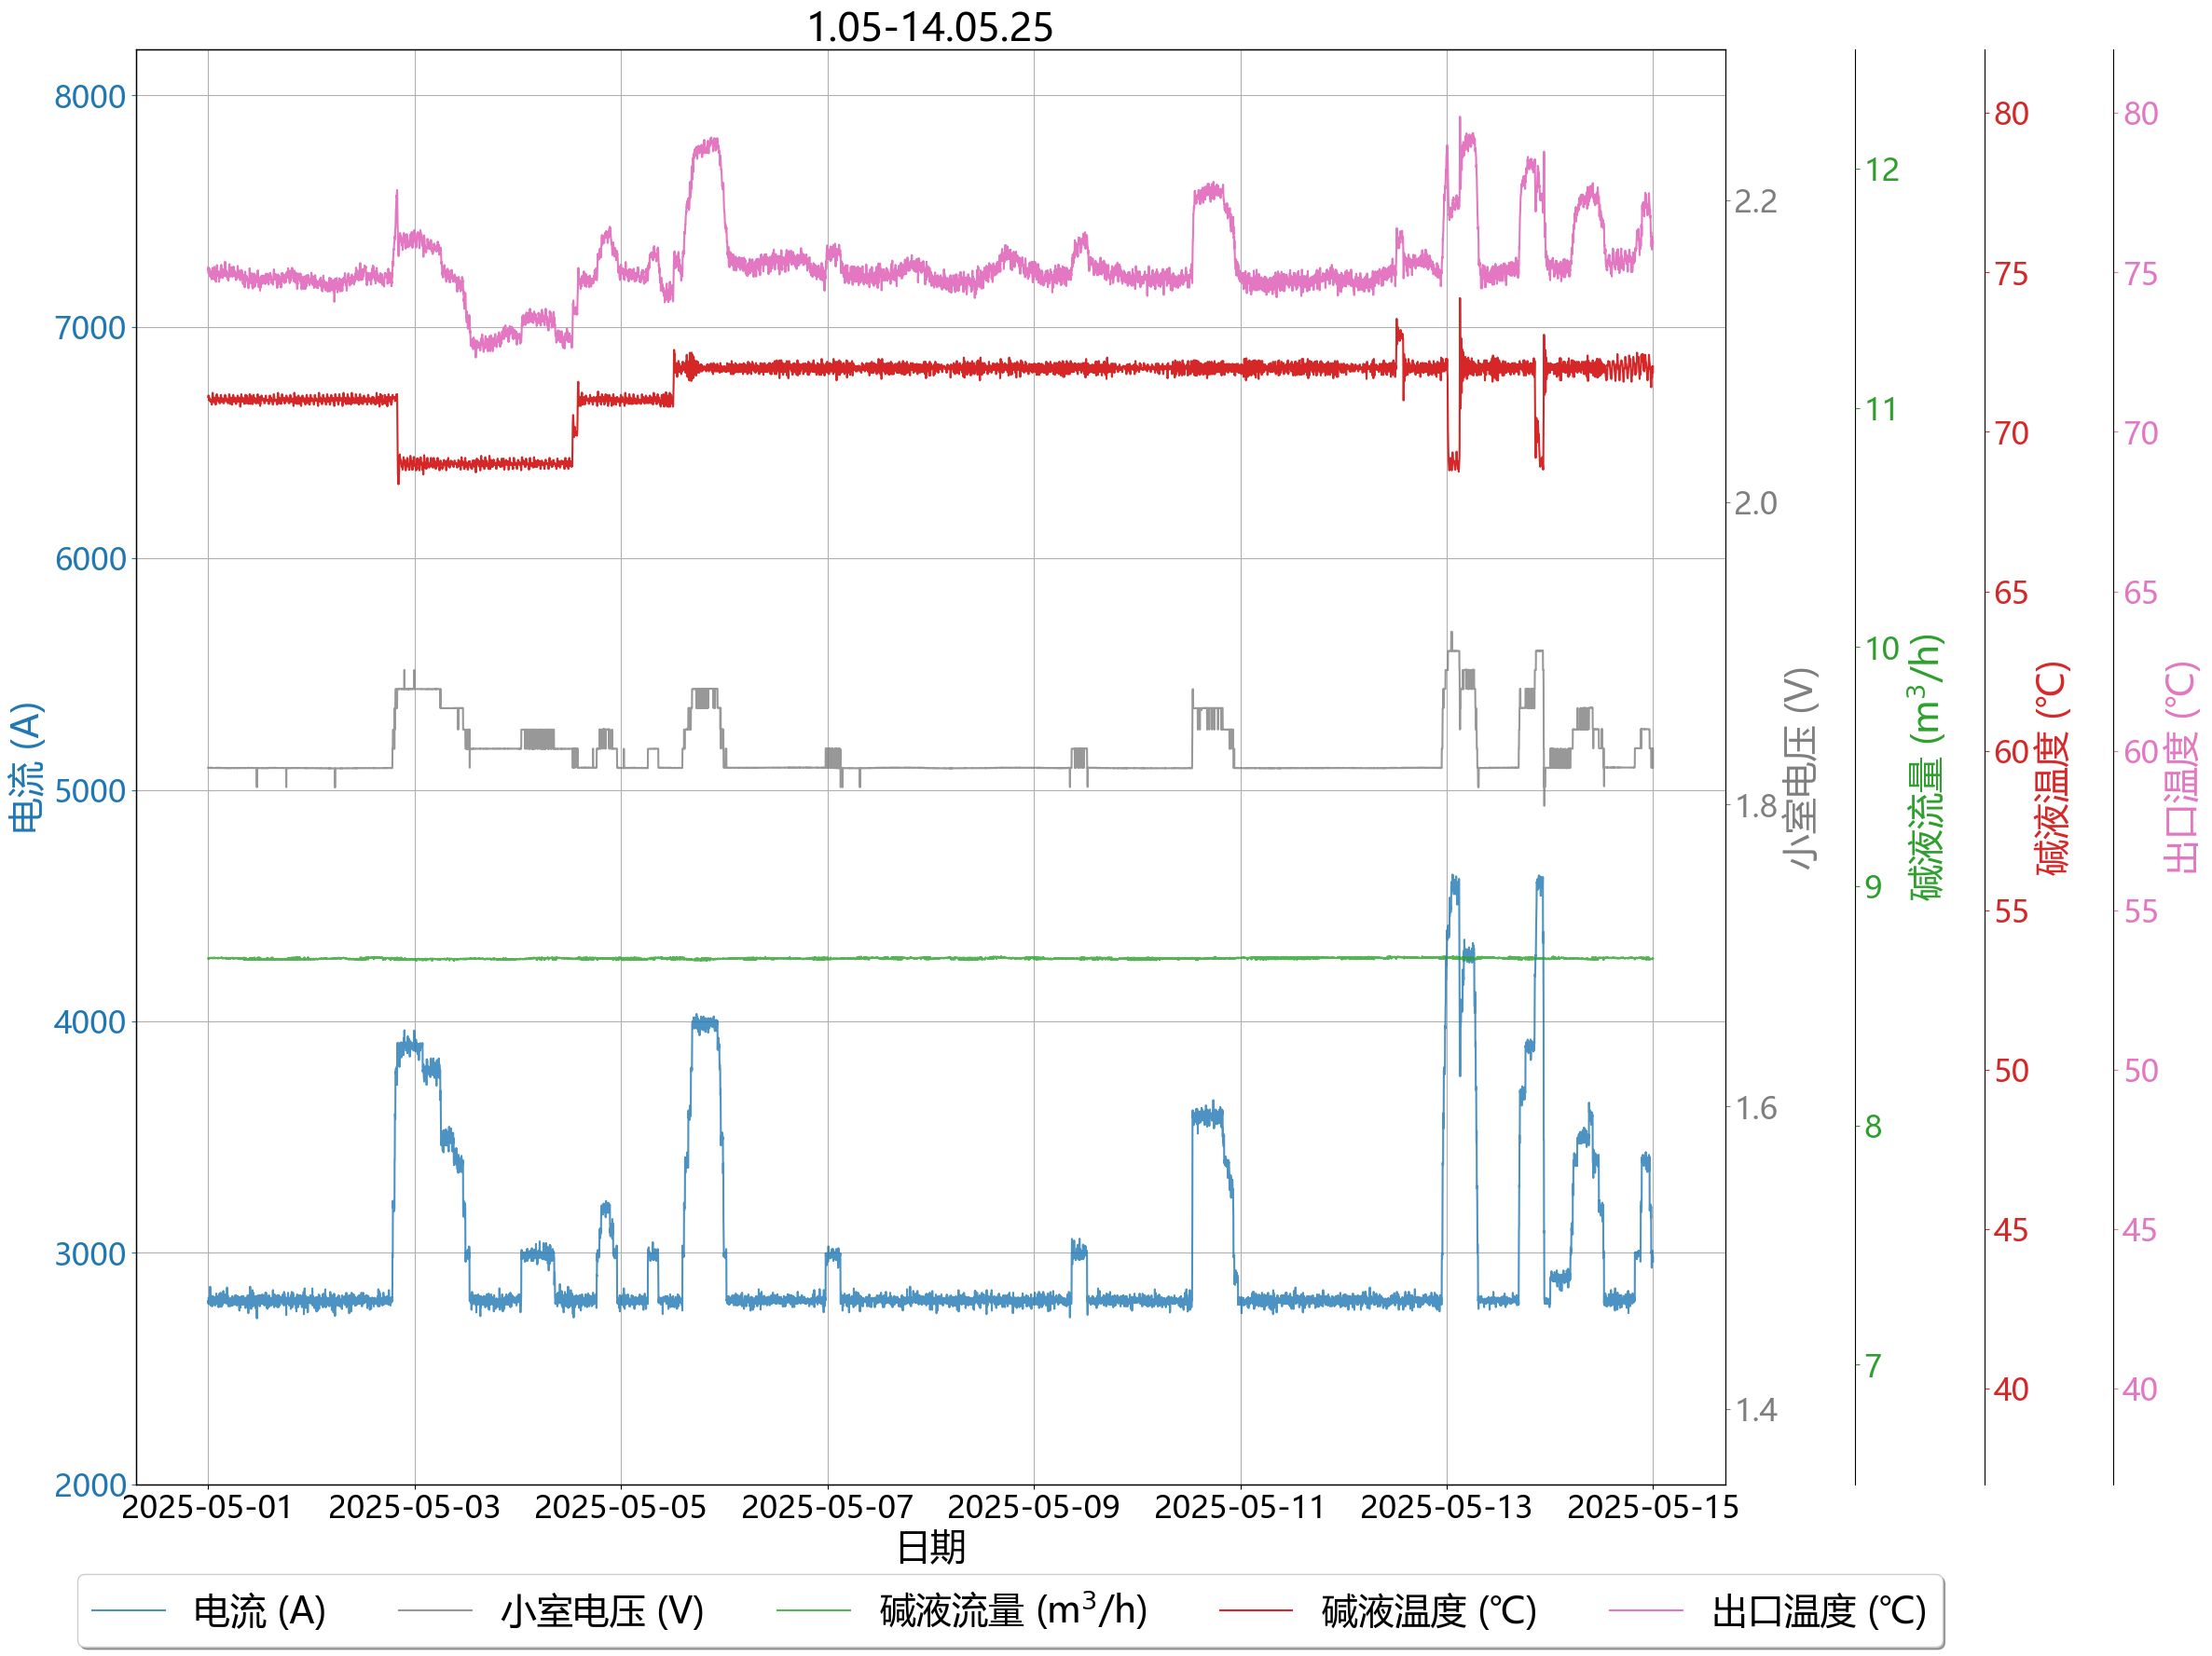

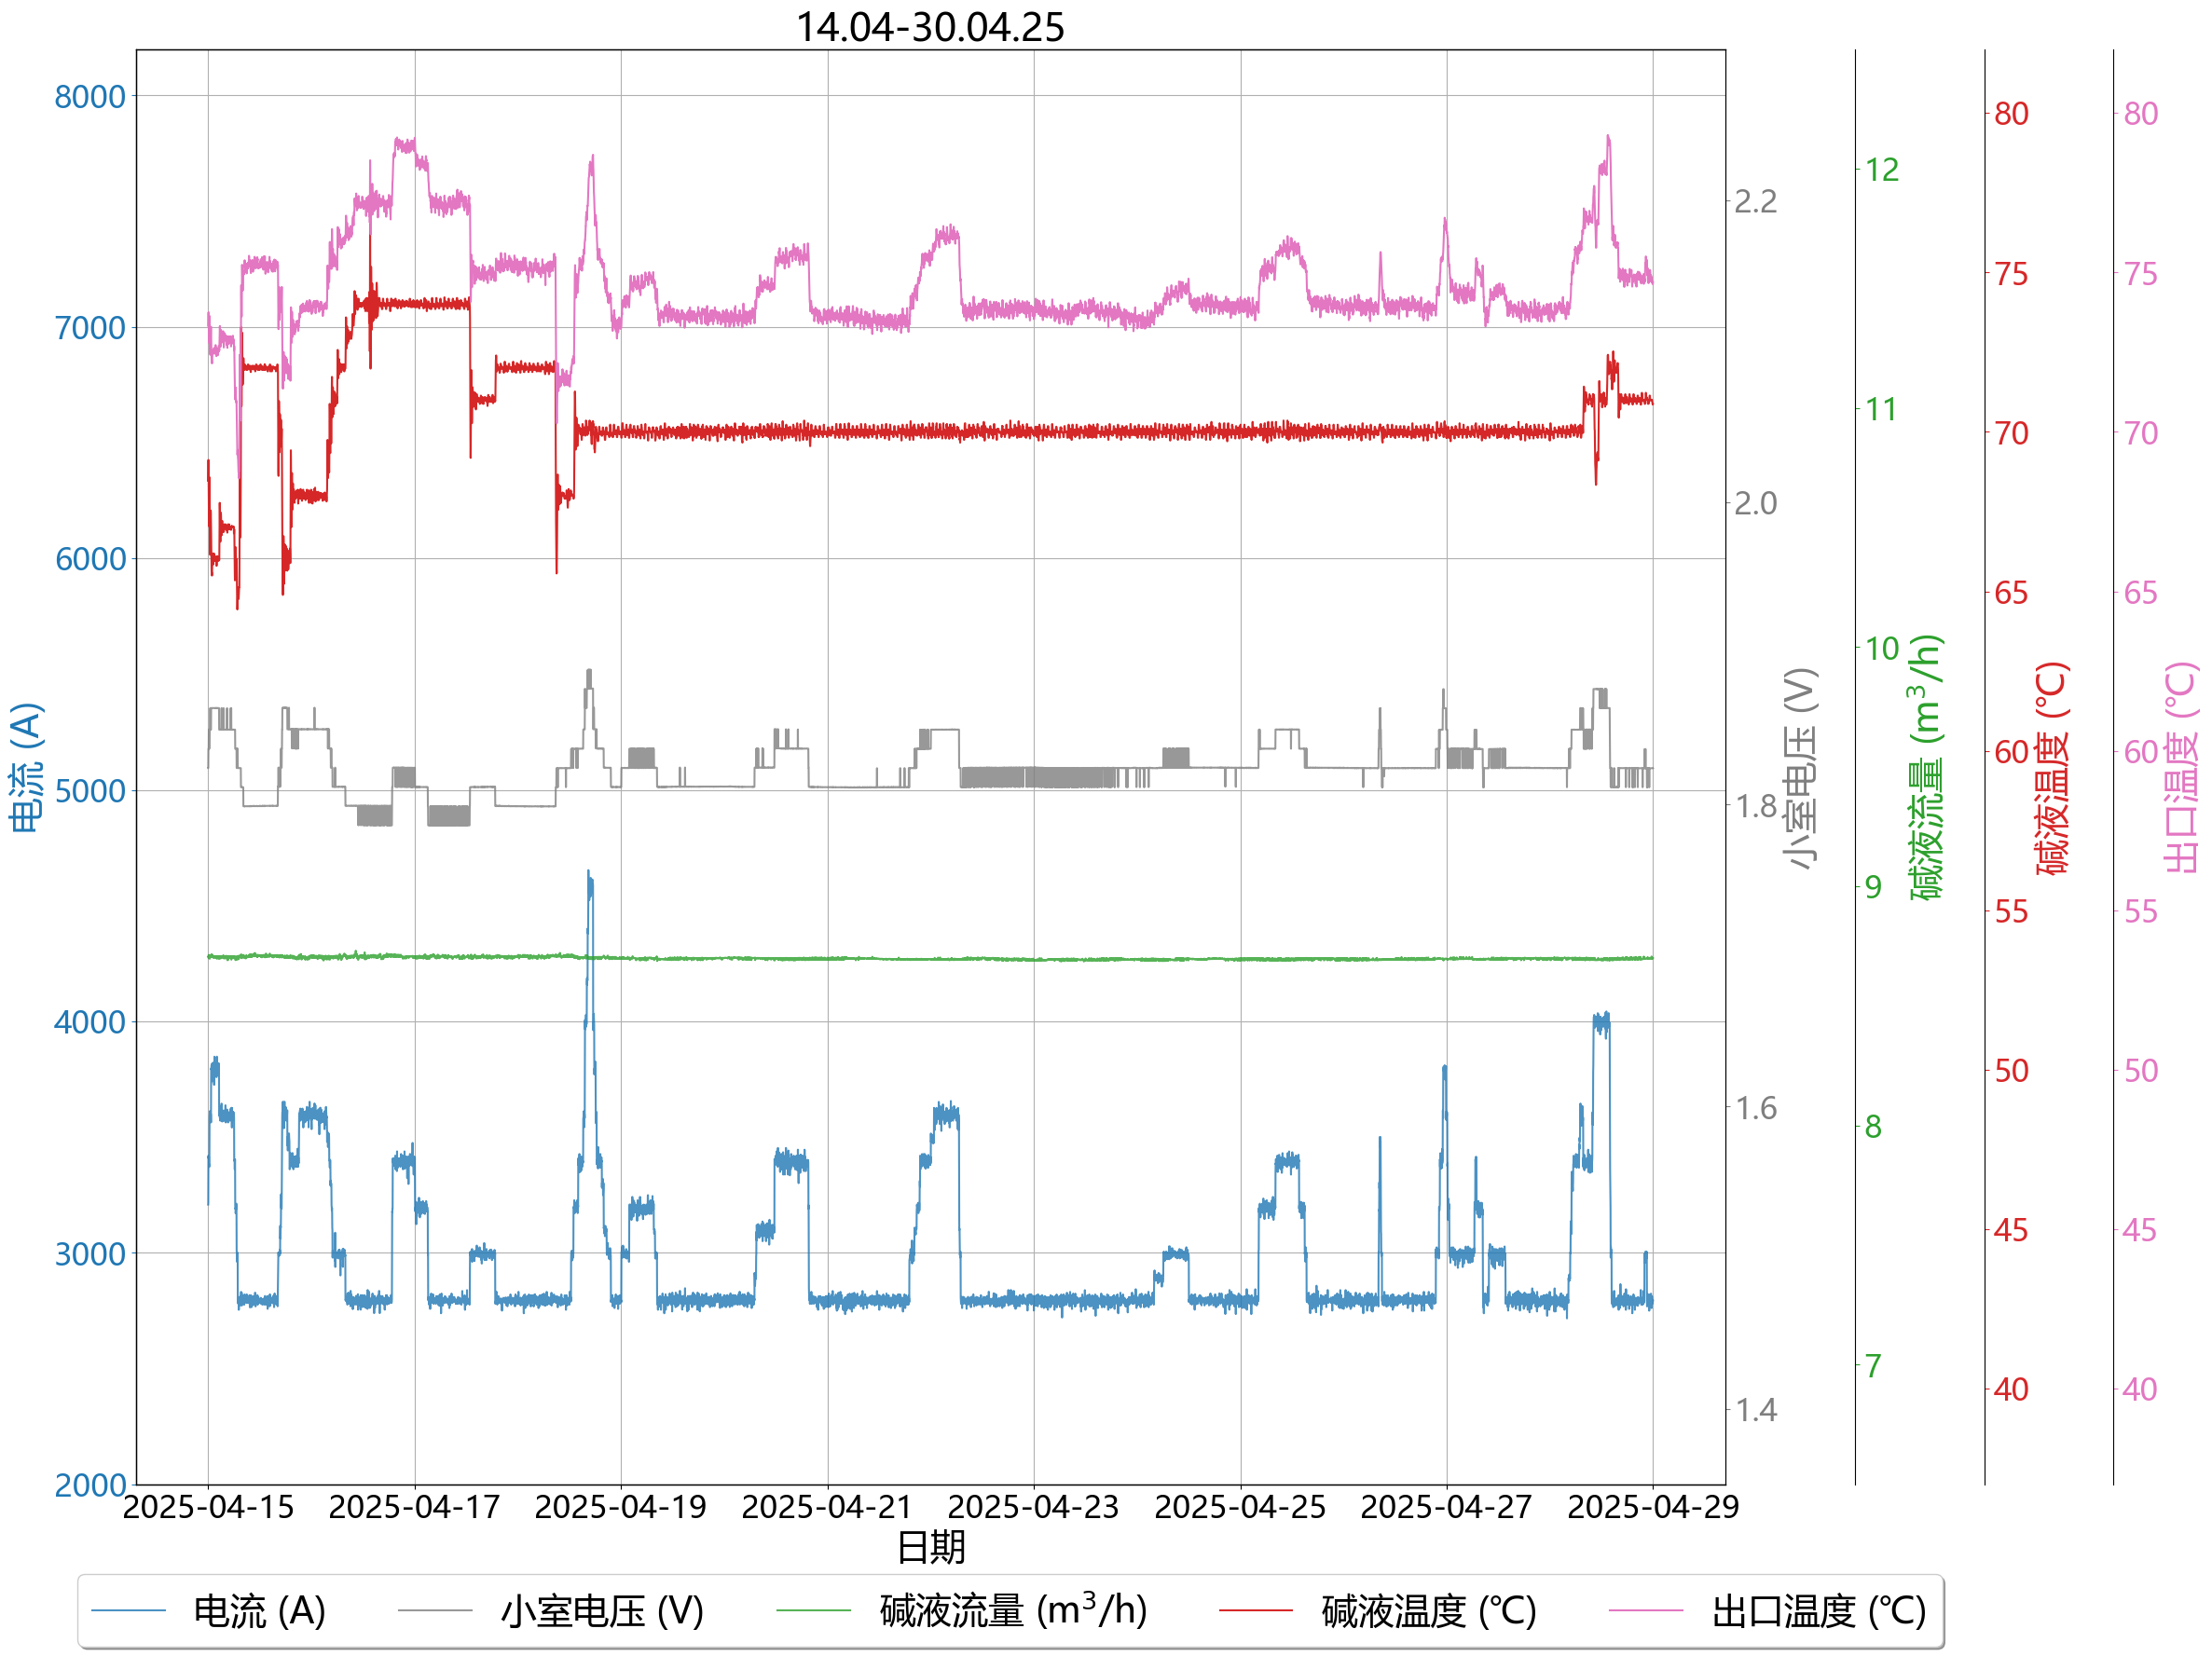

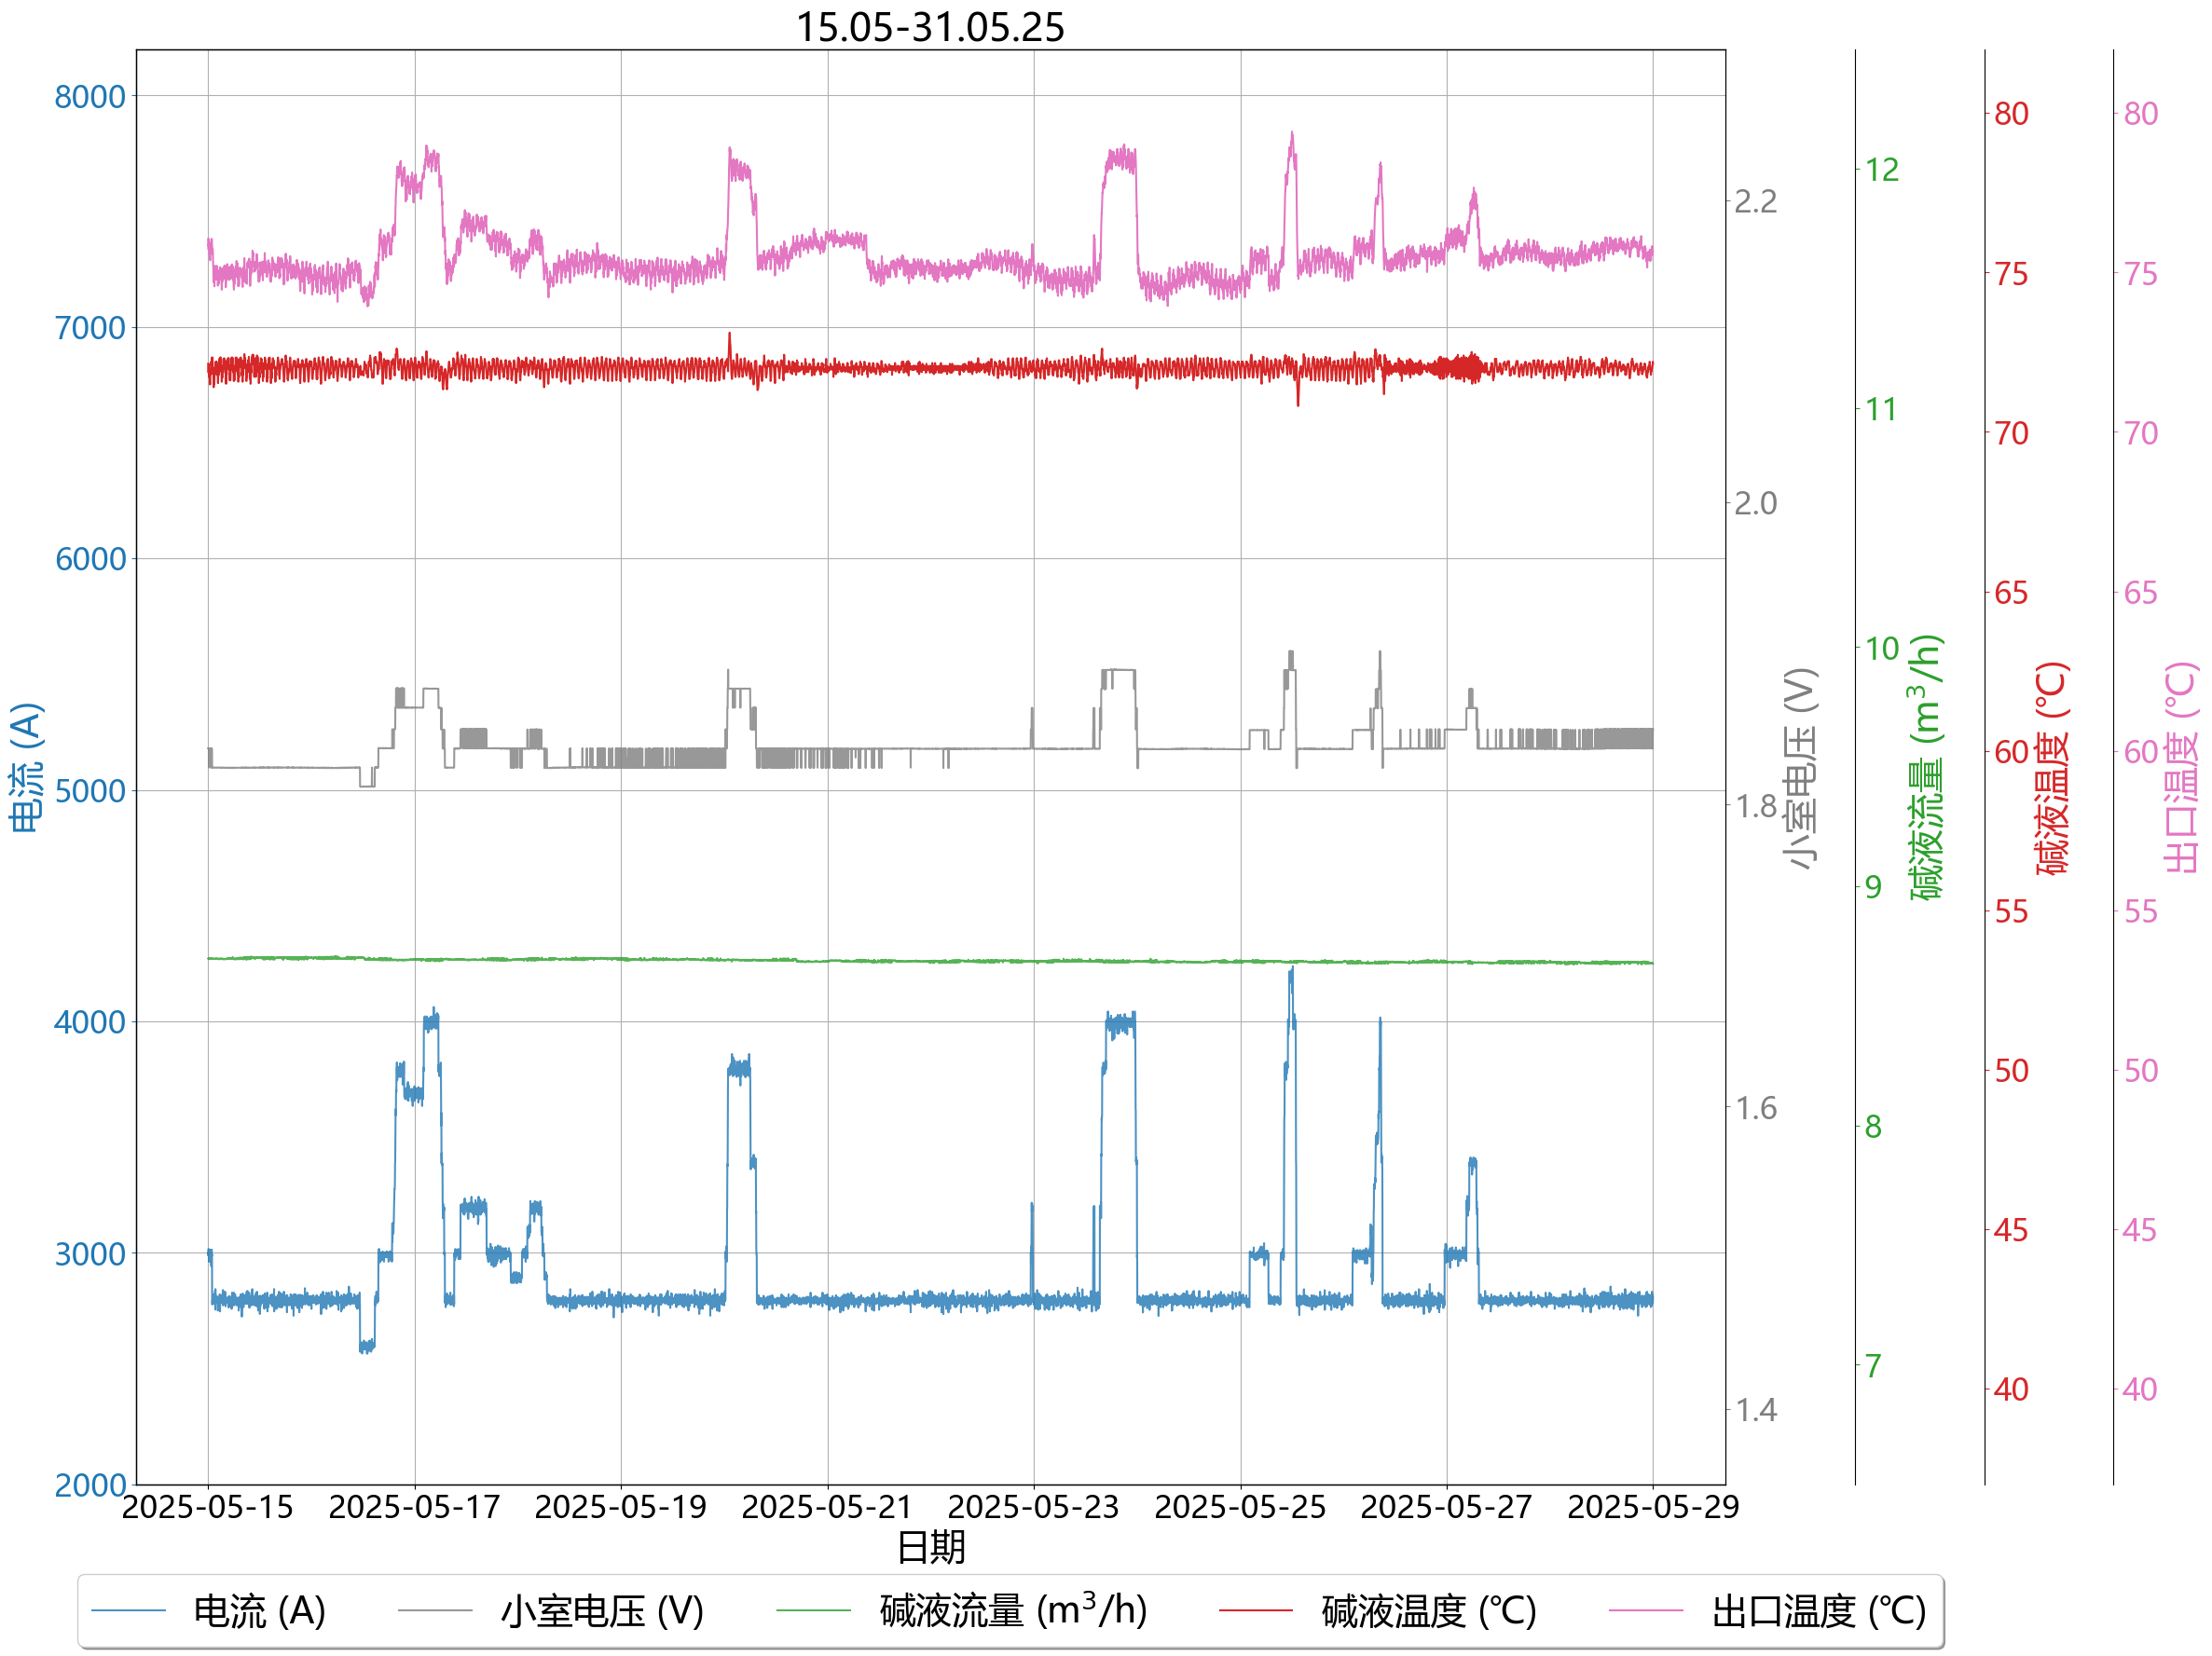

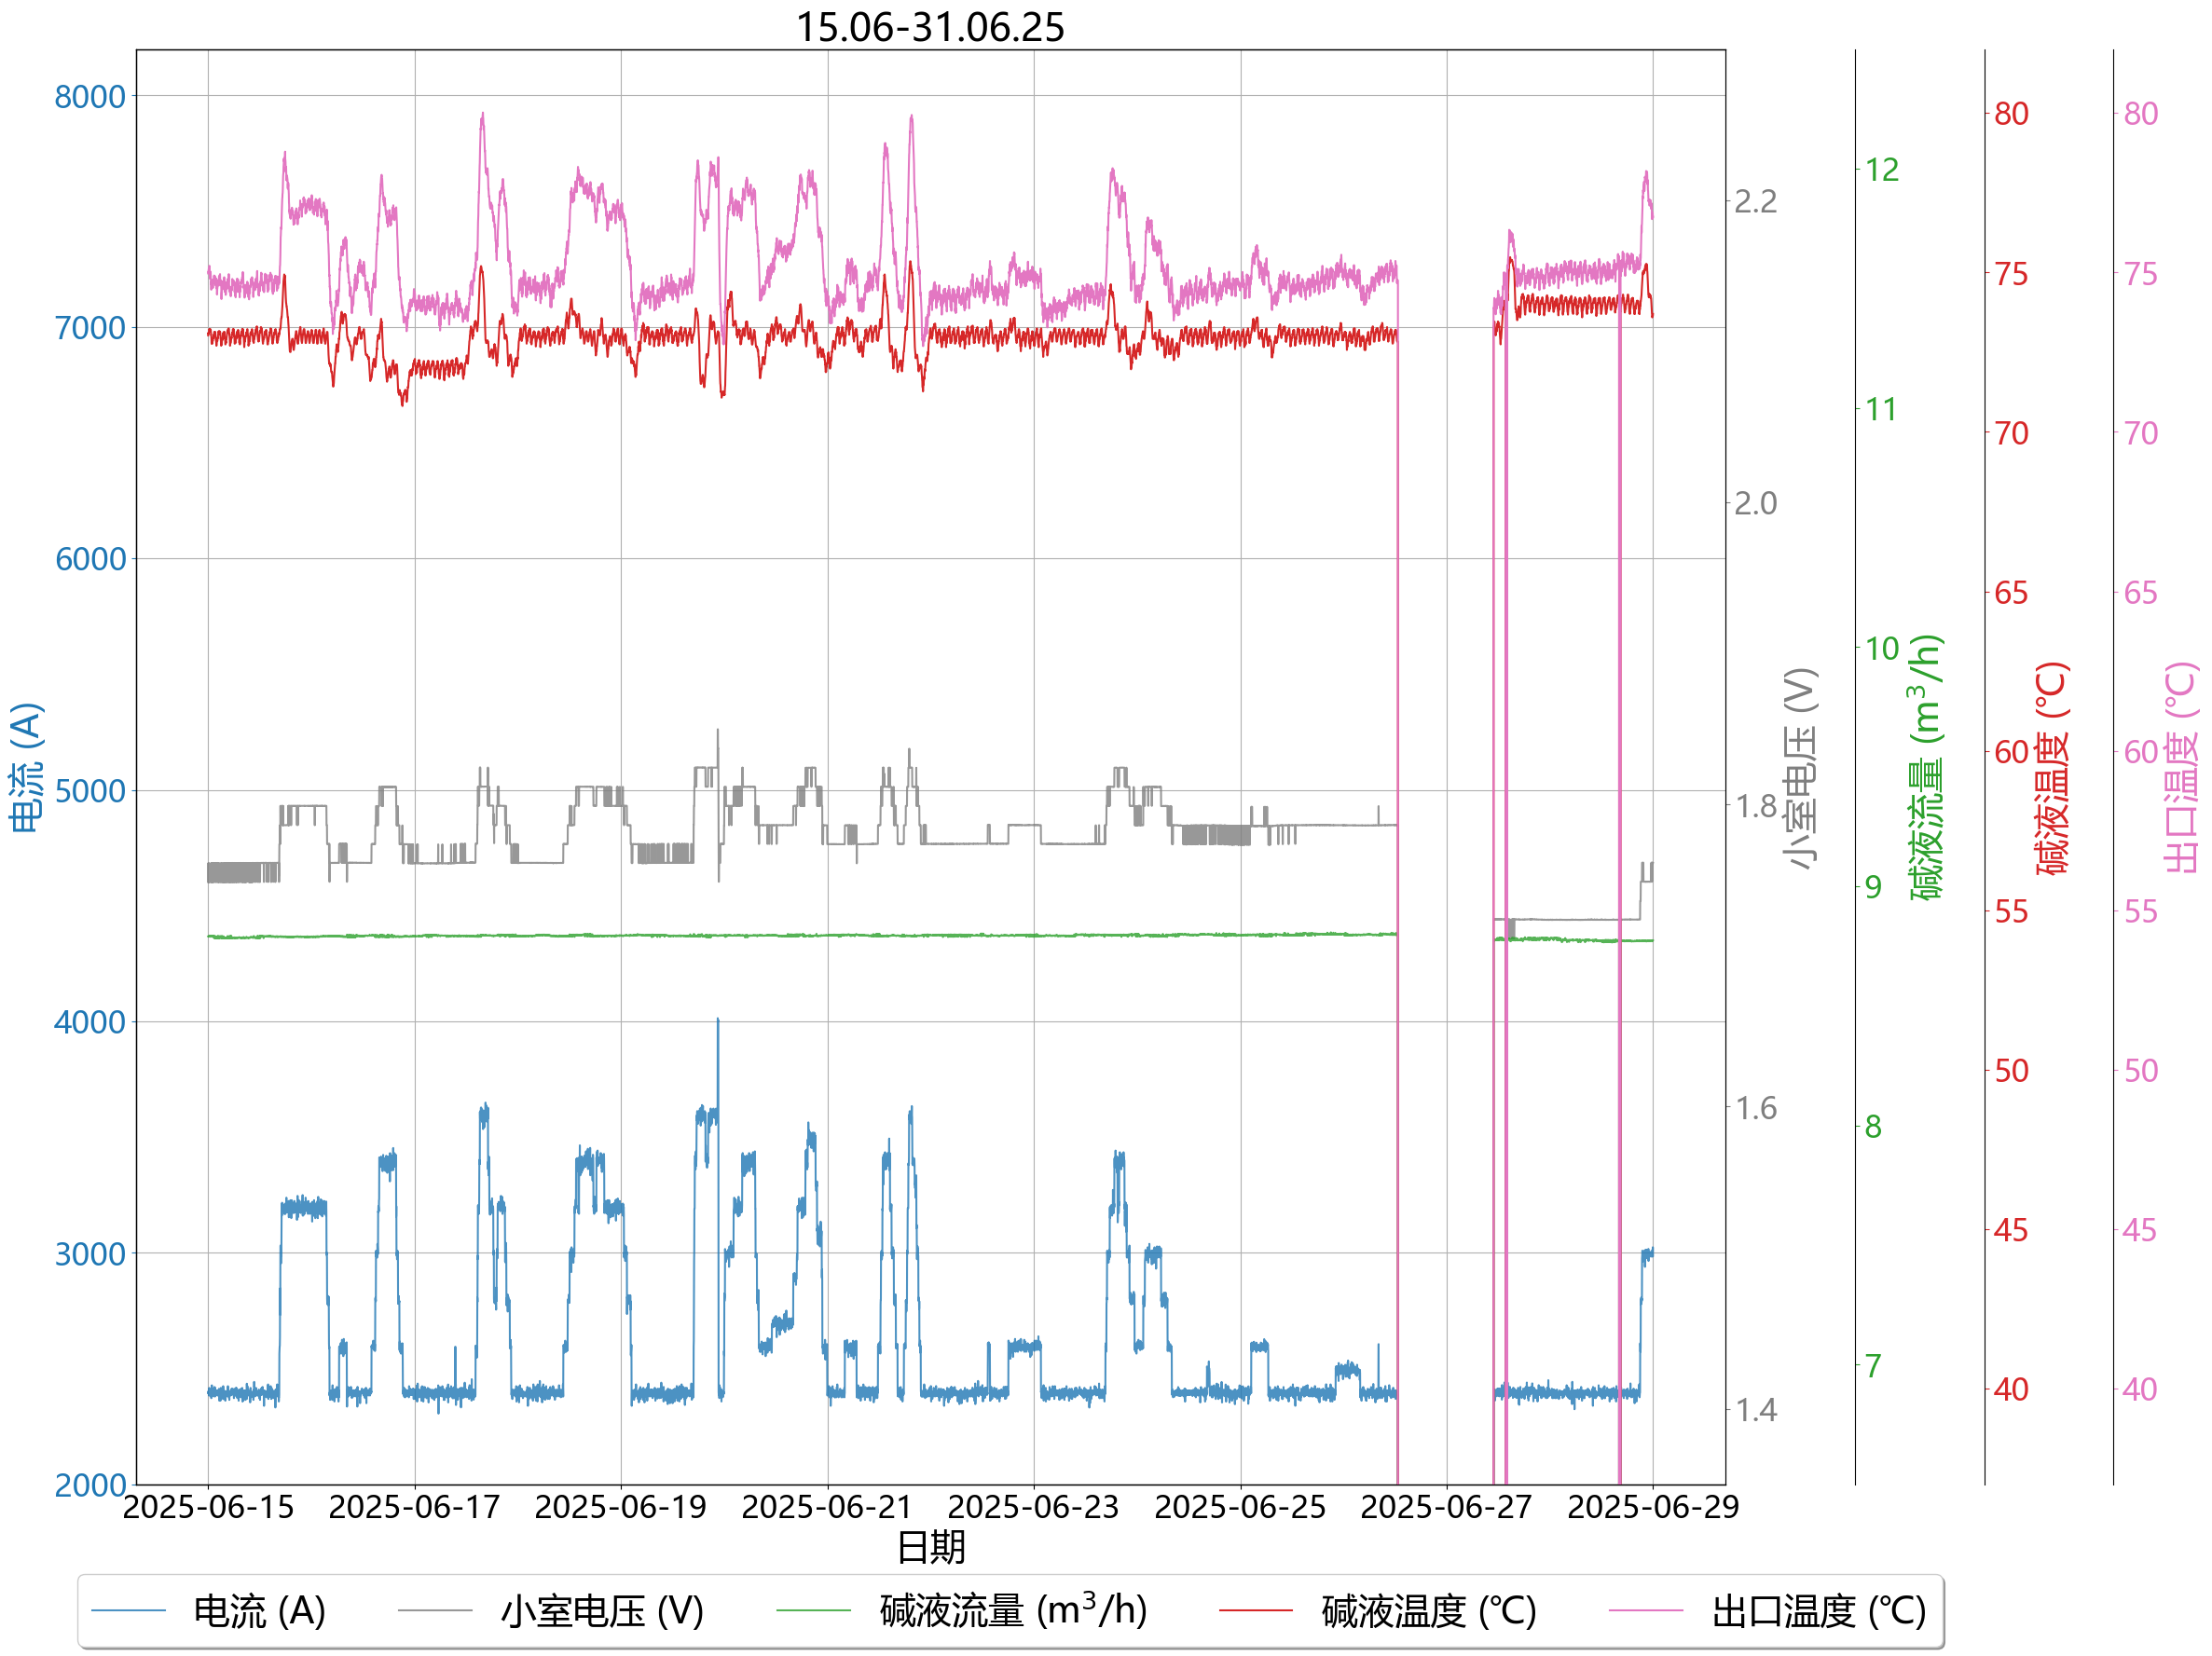

In [5]:
# 获取文件夹内的所有文件名称
file_list = os.listdir(folder_path)

# 循环依次读取每个文件
for file_name in file_list:
    
    # 绘图
    statistic_plot(file_name=file_name)